<a href="https://colab.research.google.com/github/safdarjung/GenerativeAI/blob/main/Gen_AI_Image_Colorization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print("CUDA is available")
else:
    print("CUDA is not available")

CUDA is available


In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_ds,batch_size=64,shuffle=True,num_workers=2)

test_ds = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(train_ds,batch_size=64,shuffle=False,num_workers=2)

In [15]:
class ColorizationNet(nn.Module):
  def __init__(self):
    super(ColorizationNet, self).__init__()
    self.conv1 = nn.Conv2d(1, 64, kernel_size=5, stride=1, padding=4, dilation=2)
    self.conv2 = nn.Conv2d(64, 64,  kernel_size=5, stride=1, padding=4, dilation=2)
    self.conv3 = nn.Conv2d(64, 128,  kernel_size=5, stride=1, padding=4, dilation=2)
    self.conv4 = nn.Conv2d(128, 3,  kernel_size=5, stride=1, padding=4, dilation=2)

  def forward(self,x):
    x = nn.functional.relu(self.conv1(x))
    x = nn.functional.relu(self.conv2(x))
    x = nn.functional.relu(self.conv3(x))
    x = torch.sigmoid(self.conv4(x)) # corrected activation to sigmoid
    return x

In [16]:
model = ColorizationNet().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def rgb_to_gray(img):
  return img.mean(dim=1,keepdim=True)


In [17]:
EPOCHS = 30
for epoch in range(EPOCHS):
  for i, (images, labels) in enumerate(train_loader):
    grayscale = rgb_to_gray(images).to(device)
    images = images.to(device)
    output = model(grayscale)
    loss = criterion(output, images)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 10 == 0:
      print(print(f'Epoch: {epoch+1}/{EPOCHS}, Loss: {loss.item()}'))

Epoch: 1/30, Loss: 0.06407361477613449
None
Epoch: 1/30, Loss: 0.03704571723937988
None
Epoch: 1/30, Loss: 0.02347750961780548
None
Epoch: 1/30, Loss: 0.018078705295920372
None
Epoch: 1/30, Loss: 0.01475449651479721
None
Epoch: 1/30, Loss: 0.012088870629668236
None
Epoch: 1/30, Loss: 0.01066917460411787
None
Epoch: 1/30, Loss: 0.008198538795113564
None
Epoch: 1/30, Loss: 0.011438678950071335
None
Epoch: 1/30, Loss: 0.00786642637103796
None
Epoch: 1/30, Loss: 0.008262278512120247
None
Epoch: 1/30, Loss: 0.00813062023371458
None
Epoch: 1/30, Loss: 0.007152724079787731
None
Epoch: 1/30, Loss: 0.00677729956805706
None
Epoch: 1/30, Loss: 0.0063057877123355865
None
Epoch: 1/30, Loss: 0.007340100593864918
None
Epoch: 1/30, Loss: 0.006258608773350716
None
Epoch: 1/30, Loss: 0.006172820460051298
None
Epoch: 1/30, Loss: 0.006831775419414043
None
Epoch: 1/30, Loss: 0.0065909577533602715
None
Epoch: 1/30, Loss: 0.005974910221993923
None
Epoch: 1/30, Loss: 0.005460841115564108
None
Epoch: 1/30, Los

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
  img = img/2+ 0.5
  npimg = img.numpy()

  if len(img.shape) == 2:
    plt.imshow(npimg, cmap='gray')
  else:
    plt.imshow(np.transpose(npimg, (1,2,0)))

def visualize_all_three(original_img, gray_img,color_img,n=5):
  fig= plt.figure(figsize=(3*n,4))
  for i in range(n):
    ax = plt.subplot(1,3*n,3*i+1)
    imshow(original_img[i])
    ax.set_title('Original')
    ax.axis('off')

    ax = plt.subplot(1,3*n,3*i+2)
    imshow(gray_img[i])
    ax.set_title('Grayscale')
    ax.axis('off')

    ax = plt.subplot(1,3*n,3*i+3)
    imshow(color_img[i])
    ax.set_title('Colorized')
    ax.axis('off')

  plt.tight_layout()
  plt.show()


def torch_rgb_to_hsv(rgb):
  r,g,b = rgb[:,0,:,:],rgb[:,1,:,:],rgb[:,2,:,:]
  max_val,_ = torch.max(rgb,dim=1)
  min_val,_ = torch.min(rgb,dim=1)
  diff = max_val - min_val

  h = torch.zeros_like(r)

  mask = (max_val==r)&(g>=b)
  h[mask] = (g[mask]-b[mask])/diff[mask]

  mask = (max_val==r)&(g<b)
  h[mask] = (g[mask]-b[mask])/diff[mask]+6.0

  mask = max_val==g
  h[mask] = (b[mask]-r[mask])/diff[mask]+2.0

  mask = max_val==b
  h[mask] = (r[mask]-g[mask])/diff[mask]+4.0

  h=h/6.0
  h[diff==0.0] = 0.0

  s = torch.zeros_like(r)
  s[diff!=0.0] = diff[diff!=0.0]/max_val[diff!=0.0]

  v = max_val

  return torch.stack([h,s,v], dim=1)

In [22]:
def torch_hsv_to_rgb(hsv):
  h,s,v = hsv[:,0,:,:],hsv[:,1,:,:],hsv[:,2,:,:]
  i = torch.floor(h * 6.0)
  f = h*6.0- i
  p = v*(1.0-s)
  q = v*(1.0-s*f)
  t = v*(1.0-s*(1.0-f))

  i_mod = i%6
  r = torch.zeros_like(h)
  g = torch.zeros_like(h)
  b = torch.zeros_like(h)

  r[i_mod==0.0] = v[i_mod==0.0]
  g[i_mod==0.0] = t[i_mod==0.0]
  b[i_mod==0.0] = p[i_mod==0.0]

  r[i_mod==1.0] = q[i_mod==1.0]
  g[i_mod==1.0] = v[i_mod==1.0]
  b[i_mod==1.0] = p[i_mod==1.0]

  r[i_mod==2.0] = p[i_mod==2.0]
  g[i_mod==2.0] = v[i_mod==2.0]
  b[i_mod==2.0] = t[i_mod==2.0]

  r[i_mod==3.0] = p[i_mod==3.0]
  g[i_mod==3.0] = q[i_mod==3.0]
  b[i_mod==3.0] = v[i_mod==3.0]

  r[i_mod==4.0] = t[i_mod==4.0]
  g[i_mod==4.0] = p[i_mod==4.0]
  b[i_mod==4.0] = v[i_mod==4.0]

  r[i_mod==5.0] = v[i_mod==5.0]
  g[i_mod==5.0] = p[i_mod==5.0]
  b[i_mod==5.0] = q[i_mod==5.0]


  return torch.stack([r,g,b],dim=1)

In [20]:
def exaggerate_colors(images,saturation_factor=1.5,value_factor =1.2):
  image = (images+1)/2.0
  images_hsv = torch_rgb_to_hsv(images)
  images_hsv[:,1,:] = torch.clamp(images_hsv[:,1,:]*saturation_factor,0,1)
  images_hsv[:,2,:] = torch.clamp(images_hsv[:,2,:]*value_factor,0,1)

  color_exaggerated_images = torch_hsv_to_rgb(images_hsv)
  color_exaggerated_images = color_exaggerated_images*2.0-1.0
  return color_exaggerated_images

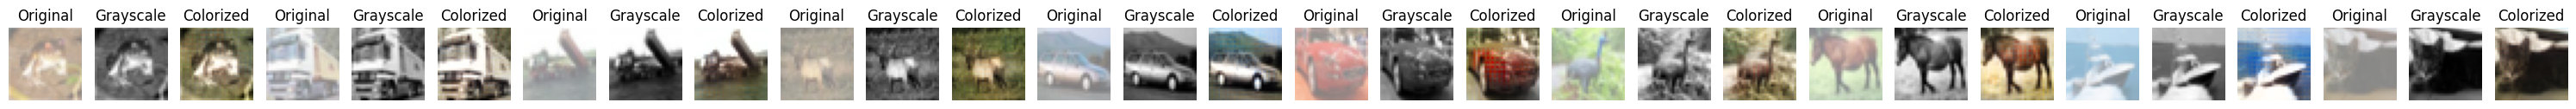

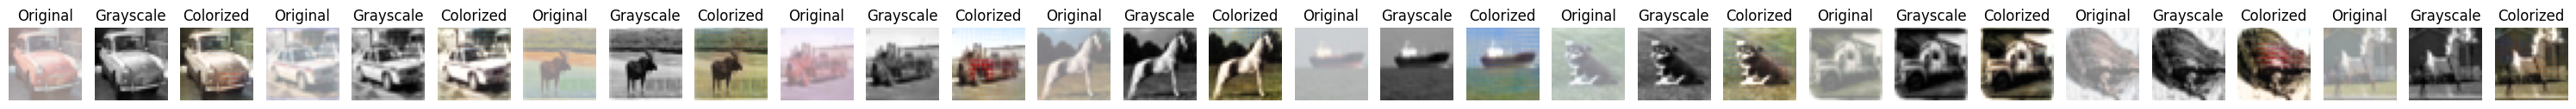

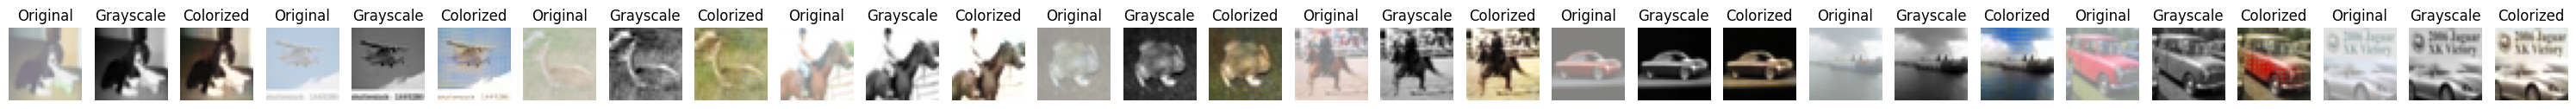

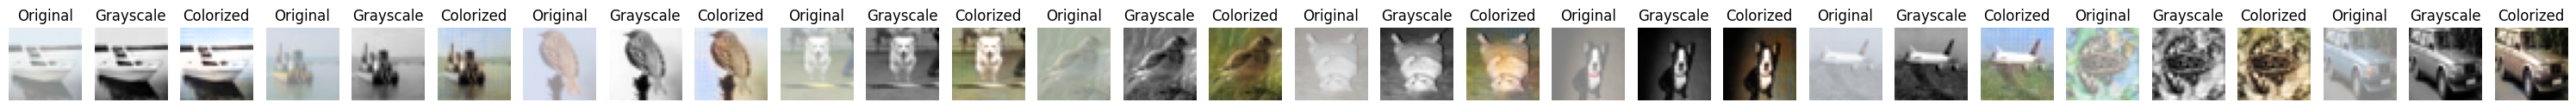

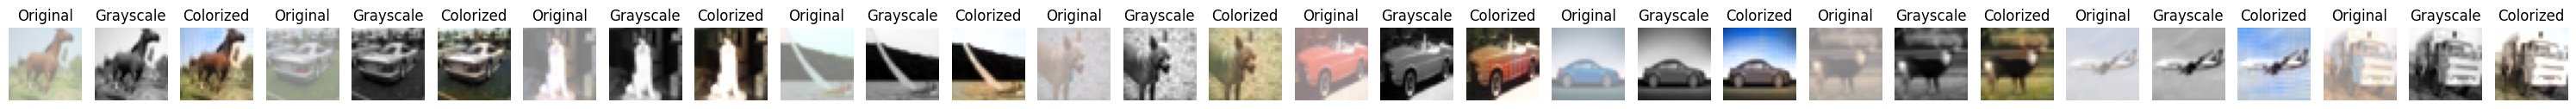

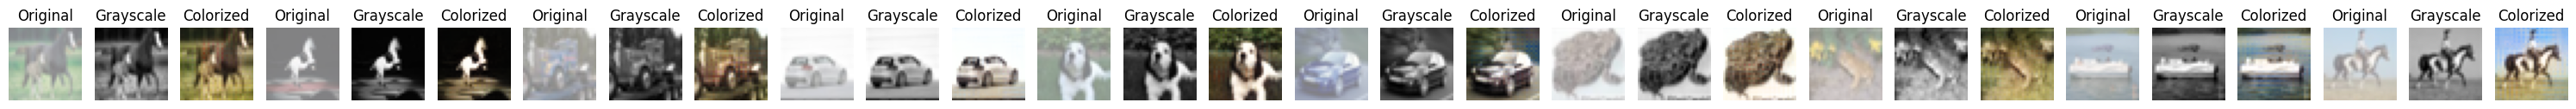

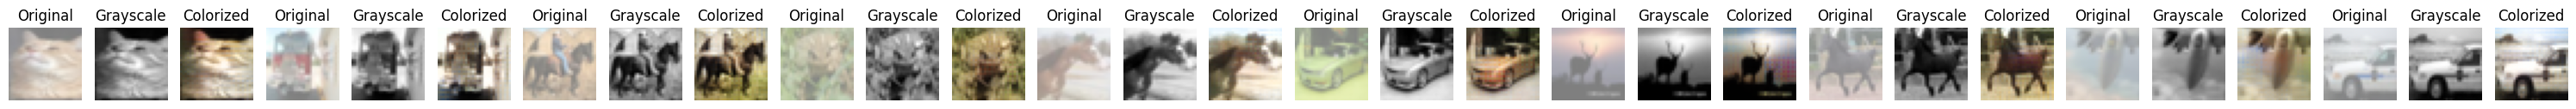

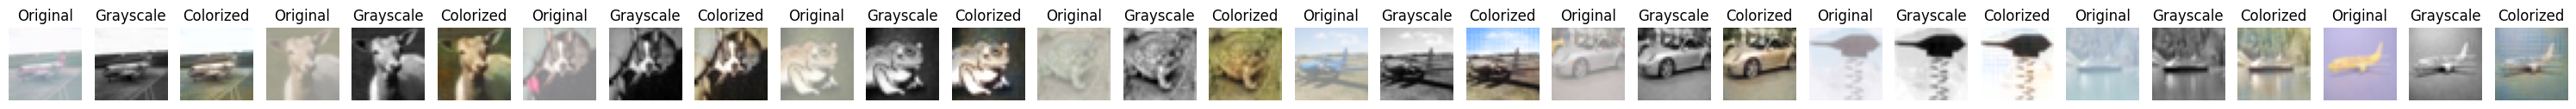

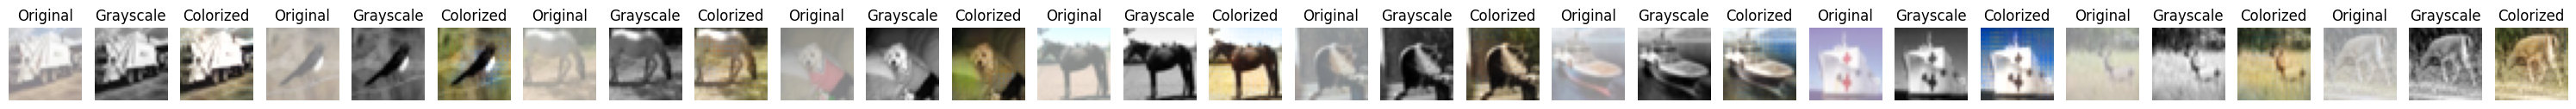

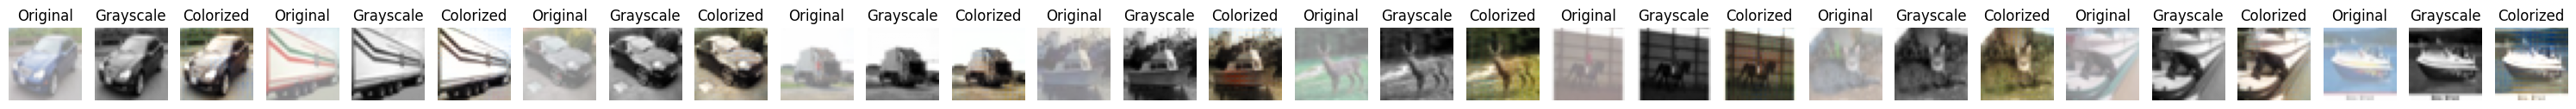

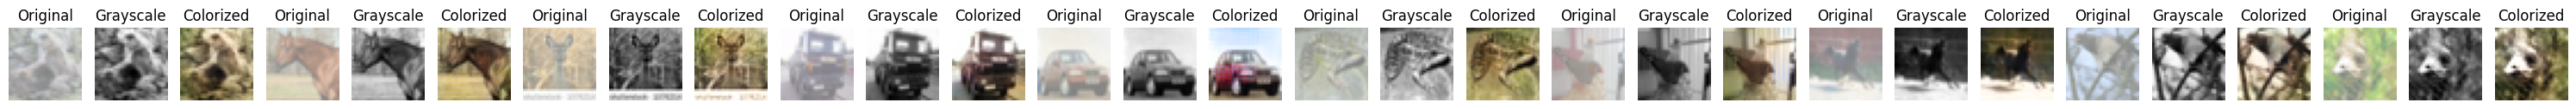

In [23]:
with torch.no_grad():
  for i,(images,_) in enumerate(test_loader):
    gray_imgs = rgb_to_gray(images).to(device)
    color_imgs = model(gray_imgs)

    gray_imgs_cpu = gray_imgs.cpu().squeeze(1)

    color_imgs_cpu = color_imgs.cpu()
    original_imgs_cpu = images.cpu()

    color_imgs_cpu = exaggerate_colors(color_imgs_cpu)

    visualize_all_three(original_imgs_cpu,gray_imgs_cpu,color_imgs_cpu,n=10)
    if i==10:
      break

In [24]:
import os

curr_dir = os.getcwd()
print("Current_directory:  ",curr_dir)


Current_directory:   /content


In [25]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print("uploaded file: ",filename )

Saving canva-medium-full-shot-farm-field-landscape-with-a-giant-moon-MAGIb-4LmOw.webp to canva-medium-full-shot-farm-field-landscape-with-a-giant-moon-MAGIb-4LmOw.webp
uploaded file:  canva-medium-full-shot-farm-field-landscape-with-a-giant-moon-MAGIb-4LmOw.webp


In [26]:
import os

files = os.listdir("/content")
print("files in current_directory: ", files)

files in current_directory:  ['.config', 'canva-medium-full-shot-farm-field-landscape-with-a-giant-moon-MAGIb-4LmOw.webp', 'data', 'sample_data']


In [27]:
from PIL import Image

img = Image.open("canva-medium-full-shot-farm-field-landscape-with-a-giant-moon-MAGIb-4LmOw.webp")
gray_img = img.convert("L")

In [28]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
])
img_tensor = transform(gray_img).unsqueeze(0)
model.eval()
img_tensor = img_tensor.to(device)
with torch.no_grad():
  color_tensor = model(img_tensor)



In [32]:
color_img = transforms.ToPILImage()(color_tensor.cpu().squeeze(0))
color_img.save("_colorized2.webp")

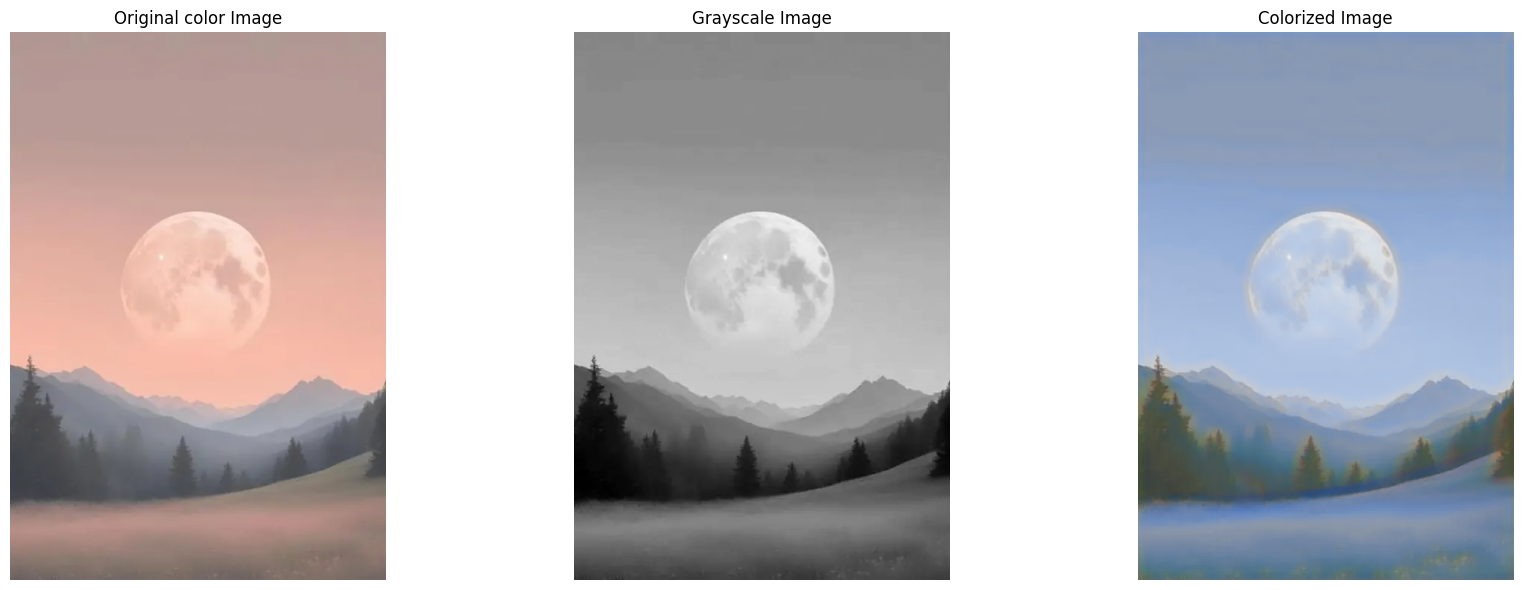

In [34]:
fig = plt.figure(figsize=(18, 6))

ax = [fig.add_subplot(1, 3, 1), fig.add_subplot(1, 3, 2), fig.add_subplot(1, 3, 3)]

ax[0].imshow(img)
ax[0].set_title("Original color Image")
ax[0].axis("off")

ax[1].imshow(gray_img,cmap="gray")
ax[1].set_title("Grayscale Image")
ax[1].axis("off")

ax[2].imshow(color_img)
ax[2].set_title("Colorized Image")
ax[2].axis("off")

plt.tight_layout()
plt.show()